## INTRODUCTION

This notebook contains a systematic process of exploratory data analysis and data preprocessing in order to produce data-driven decision making and reliable data for developing the machine learning model later.

dataset: Chexpert Plus (https://aimi.stanford.edu/datasets/chexpert-plus).

## 1. Import Library and Initial Configuration

In [1]:
# import necessary library
import pandas as pd
from pathlib import Path
import json
import os
import random
import re
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import numpy as np
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [2]:
# define configuration
SEED = 42
BASE_DIR = Path("D:/VLM-Research_Task-C/data/raw/chexpert_plus/vlm_fah/dataset/chexpertplus")
CSV_PATH = Path("D:/VLM-Research_Task-C/data/raw/chexpert_plus/df_chexpert_plus_240401.csv")

In [3]:
# setup reproducibility
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(SEED)

## 2. Load Data

In [4]:
# load dataset into dataframe
df = pd.read_csv(CSV_PATH)

In [5]:
# load labels of findings text
df_findings_label = pd.read_json(BASE_DIR / "label/findings_fixed.json", lines=True)

# load labels of impression text
df_impression_label = pd.read_json(BASE_DIR / "label/impression_fixed.json", lines=True)

# merge dataset
df_full = df.merge(df_findings_label, on='path_to_image', how='inner').merge(df_impression_label, on='path_to_image', how='inner').copy()

In [6]:
# check for the completeness of `df_full` compared to `df`
print(f"original shape: {df.shape}")
print(f"merged shape: {df_full.shape}")

original shape: (223462, 27)
merged shape: (223462, 55)


In [7]:
# synchronize image path
def sync_image_path(row):
    # .jpg to .png
    pure_path = Path(row['path_to_image']).with_suffix('.png')
    # adjust path
    full_path = BASE_DIR / "preprocessed" / "PNG" / pure_path
    return str(full_path)
df_full['actual_image_path'] = df_full.apply(sync_image_path, axis=1)

In [8]:
# check for the success of image path synchronization
df_full[['path_to_image', 'actual_image_path', 'section_findings', 'section_impression']].head()

,path_to_image,actual_image_path,section_findings,section_impression
0,train/patient00003/study1/view1_frontal.jpg,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...,"Costophrenic angles sharp, without evidence o...",\n1. NO EVIDENCE OF PNEUMOTHORAX.\n2. MILD INT...
1,train/patient00007/study2/view1_frontal.jpg,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...,NaN,\n \nLow lung volumes. Stable moderate enlar...
2,train/patient00007/study1/view1_frontal.jpg,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...,NaN,"\n \nLow lung volumes, and overlying trauma b..."
3,train/patient00009/study1/view2_lateral.jpg,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...,NaN,\n1. PA AND LATERAL CHEST RADIOGRAPH. THE HEAR...
4,train/patient00009/study1/view1_frontal.jpg,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...,NaN,\n1. PA AND LATERAL CHEST RADIOGRAPH. THE HEAR...


In [9]:
# initialize a duplicate dataframe for EDA needs
df_eda = df_full.copy()

## 3. Exploratory Data Analysis (EDA)

In [10]:
# preview for the first five samples
df_eda.head()

,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,Consolidation_y,Pneumonia_y,Atelectasis_y,Pneumothorax_y,Pleural Effusion_y,Pleural Other_y,Fracture_y,Support Devices_y,No Finding_y,actual_image_path
0,train/patient00003/study1/view1_frontal.jpg,train/patient00003/study1/view1_frontal.dcm,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...","\nCHEST, ONE VIEW: 2-10-2001\n",NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...
1,train/patient00007/study2/view1_frontal.jpg,train/patient00007/study2/view1_frontal.dcm,Frontal,AP,patient00007,2,NARRATIVE:\nChest 1 View: July 20\n \nHISTORY:...,\nChest 1 View: July 20\n \n,NaN,"Male, 69 years old, intubated.\n \n",...,NaN,NaN,1.0,0.0,0.0,NaN,0.0,1.0,NaN,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...
2,train/patient00007/study1/view1_frontal.jpg,train/patient00007/study1/view1_frontal.dcm,Frontal,AP,patient00007,1,NARRATIVE:\nChest 1 View: 12-28-2000\n \nHISTO...,\nChest 1 View: 12-28-2000\n \n,NaN,"Male, 69 years old, Check tube placement.\n \n",...,NaN,NaN,1.0,0.0,0.0,NaN,0.0,1.0,NaN,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...
3,train/patient00009/study1/view2_lateral.jpg,train/patient00009/study1/view2_lateral.dcm,Lateral,NaN,patient00009,1,NARRATIVE:\nCHEST X-RAY: 2/21/2006\nCOMPARISON...,\nCHEST X-RAY: 2/21/2006\n,Dyspnea. Multiple myeloma.\n,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...
4,train/patient00009/study1/view1_frontal.jpg,train/patient00009/study1/view1_frontal.dcm,Frontal,PA,patient00009,2,NARRATIVE:\nCHEST X-RAY: 4/27/07\nCOMPARISON: ...,\nCHEST X-RAY: 4/27/07\n,Dyspnea. Multiple myeloma.\n,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...


In [11]:
# preview for the last five samples
df_eda.tail()

,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,Consolidation_y,Pneumonia_y,Atelectasis_y,Pneumothorax_y,Pleural Effusion_y,Pleural Other_y,Fracture_y,Support Devices_y,No Finding_y,actual_image_path
223457,train/patient63745/study1/view1_frontal.jpg,train/patient63745/study1/view1_frontal.dcm,Frontal,AP,patient63745,1,NARRATIVE:\nCHEST: AUGUST 2001\n \n COMPARISO...,\nCHEST: AUGUST 2001\n \n,The patient is a 57-year-old male with pneum...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...
223458,train/patient63986/study1/view1_frontal.jpg,train/patient63986/study1/view1_frontal.dcm,Frontal,AP,patient63986,1,"NARRATIVE:\nEXAM: Chest 1 View, 9/12/2009.\n \...","\nEXAM: Chest 1 View, 9/12/2009.\n \n",NaN,"Female who is of 37 years, Chest pain acute o...",...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,1.0,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...
223459,train/patient64064/study1/view1_frontal.jpg,train/patient64064/study1/view1_frontal.dcm,Frontal,AP,patient64064,1,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 10-30-2...,\nSINGLE VIEW OF THE CHEST: 10-30-2015\n \n,A 62-year-old female with history of subarac...,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...
223460,train/patient64079/study1/view1_frontal.jpg,train/patient64079/study1/view1_frontal.dcm,Frontal,AP,patient64079,1,"NARRATIVE:\nPORTABLE CHEST, SINGLE VIEW, 12/17...","\nPORTABLE CHEST, SINGLE VIEW, 12/17/2019 secu...",Trauma.\n,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,1.0,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...
223461,valid/patient64739/study1/view1_frontal.jpg,valid/patient64739/study1/view1_frontal.dcm,Frontal,AP,patient64739,1,NARRATIVE:\nCOMPARISON: 7-21-2005\n \nIMPRESSI...,\n,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,D:\VLM-Research_Task-C\data\raw\chexpert_plus\...


In [12]:
# list of columns
df_eda.columns

Index(['path_to_image', 'path_to_dcm', 'frontal_lateral', 'ap_pa',
       'deid_patient_id', 'patient_report_date_order', 'report',
       'section_narrative', 'section_clinical_history', 'section_history',
       'section_comparison', 'section_technique', 'section_procedure_comments',
       'section_findings', 'section_impression', 'section_end_of_impression',
       'section_summary', 'section_accession_number', 'age', 'sex', 'race',
       'ethnicity', 'interpreter_needed', 'insurance_type', 'recent_bmi',
       'deceased', 'split', 'Enlarged Cardiomediastinum_x', 'Cardiomegaly_x',
       'Lung Opacity_x', 'Lung Lesion_x', 'Edema_x', 'Consolidation_x',
       'Pneumonia_x', 'Atelectasis_x', 'Pneumothorax_x', 'Pleural Effusion_x',
       'Pleural Other_x', 'Fracture_x', 'Support Devices_x', 'No Finding_x',
       'Enlarged Cardiomediastinum_y', 'Cardiomegaly_y', 'Lung Opacity_y',
       'Lung Lesion_y', 'Edema_y', 'Consolidation_y', 'Pneumonia_y',
       'Atelectasis_y', 'Pneumothor

In [13]:
# split set distribution
df_eda['split'].value_counts()

split
train    223228
valid       234
Name: count, dtype: int64

In [14]:
# distribution of viewing angle
df_eda.groupby('split')['frontal_lateral'].value_counts().unstack()

frontal_lateral,Frontal,Lateral
split,,
train,190869,32359
valid,202,32


In [15]:
# distribution of X-ray imaging projections
df_eda.groupby(['split', 'frontal_lateral'])['ap_pa'].value_counts(dropna=False).unstack(fill_value=0)

ap_pa                      AP  LL     PA  RL    NaN
split frontal_lateral                              
train Frontal          161453  16  29399   1      0
      Lateral               0   0      0   0  32359
valid Frontal             169   0     33   0      0
      Lateral               0   0      0   0     32

In [16]:
# distribution alignment with path name
# path: [split]/patientxxxx/studyx/viewx_[frontal_lateral].jpg

# validating frontal/lateral labels using the image file path string
path_view = df_eda['path_to_image'].str.lower().apply(lambda x: 'lateral' if 'lateral' in x else ('frontal' if 'frontal' in x else 'unknown'))
df_eda.groupby(['split', 'frontal_lateral', path_view])['ap_pa'].value_counts(dropna=False).unstack(fill_value=0)

ap_pa                                    AP  LL     PA  RL    NaN
split frontal_lateral path_to_image                              
train Frontal         frontal        161453  16  29399   1      0
      Lateral         lateral             0   0      0   0  32359
valid Frontal         frontal           169   0     33   0      0
      Lateral         lateral             0   0      0   0     32

Key Takeaways:
- frontal = A looking-straight-on perspective of the body.
- lateral = A looking-from-the-side profile perspective of the body.
- Both AP and PA projections should fall under "frontal" category.
- Both LL and RL projections should fall under "lateral" category.
- Both LL and RL projections should fall under "lateral" category, but 17 of them (all in train split: 16 LL, 1 RL) are misclassified as "frontal".
- 100% of data genuinely labeled as "lateral" have missing values (NaN) in their `ap_pa` column.
- Hypothesis: the 17 lateral projections (16 ll, 1 rl) found in the frontal row are actually frontal images, as confirmed by their image file paths.
- The 17 misclassified anomalies occur exclusively within the train split, leaving the valid split clean.
- The missing details (nan) in ap_pa for lateral views are true lateral images since their file paths consistently match the lateral label.

In [17]:
# CheXpert multilabel distribution of findings text
findings_cols = [
    'Enlarged Cardiomediastinum_x', 'Cardiomegaly_x', 'Lung Opacity_x', 
    'Lung Lesion_x', 'Edema_x', 'Consolidation_x', 'Pneumonia_x', 
    'Atelectasis_x', 'Pneumothorax_x', 'Pleural Effusion_x', 
    'Pleural Other_x', 'Fracture_x', 'Support Devices_x', 'No Finding_x'
]
df_eda.groupby('split')[findings_cols].apply(lambda g: g.apply(lambda x: x.value_counts(dropna=False))).unstack(level=0).fillna(0).T

-1.0      0.0       1.0       NaN
                             split                                     
Enlarged Cardiomediastinum_x train  6902.0  12907.0    4126.0  199293.0
                             valid     7.0     21.0       4.0     202.0
Cardiomegaly_x               train  1554.0  11247.0   10953.0  199474.0
                             valid     0.0     14.0      18.0     202.0
Lung Opacity_x               train   105.0   1485.0   32329.0  189309.0
                             valid     0.0      3.0      29.0     202.0
Lung Lesion_x                train   459.0    329.0    3486.0  218954.0
                             valid     0.0      0.0       4.0     230.0
Edema_x                      train  2684.0   4432.0   12137.0  203975.0
                             valid     3.0     11.0      11.0     209.0
Consolidation_x              train  5932.0   7075.0    4152.0  206069.0
                             valid     6.0      8.0       7.0     213.0
Pneumonia_x                  train  3699.0    381.0     915.0  218233.0
                             valid     3.0      0.0       0.0     231.0
Atelectasis_x                train  8362.0    167.0    9123.0  205576.0
                             valid     9.0      0.0      13.0     212.0
Pneumothorax_x               train   702.0  18555.0    6384.0  197587.0
                             valid     0.0     22.0       7.0     205.0
Pleural Effusion_x           train  2278.0  10571.0   24488.0  185891.0
                             valid     3.0     15.0      23.0     193.0
Pleural Other_x              train   759.0     13.0    1659.0  220797.0
                             valid     0.0      0.0       4.0     230.0
Fracture_x                   train   148.0   2747.0    3265.0  217068.0
                             valid     0.0      3.0       1.0     230.0
Support Devices_x            train     1.0    376.0   31674.0  191177.0
                             valid     0.0      1.0      36.0     197.0
No Finding_x                 train     0.0      0.0  167768.0   55460.0
                             valid     0.0      0.0     165.0      69.0

In [18]:
# CheXpert multilabel distribution of impression text
impression_cols = [
    'Enlarged Cardiomediastinum_y', 'Cardiomegaly_y', 'Lung Opacity_y', 
    'Lung Lesion_y', 'Edema_y', 'Consolidation_y', 'Pneumonia_y', 
    'Atelectasis_y', 'Pneumothorax_y', 'Pleural Effusion_y', 
    'Pleural Other_y', 'Fracture_y', 'Support Devices_y', 'No Finding_y'
]
df_eda.groupby('split')[impression_cols].apply(lambda g: g.apply(lambda x: x.value_counts(dropna=False))).unstack(level=0).fillna(0).T

-1.0      0.0       1.0       NaN
                             split                                      
Enlarged Cardiomediastinum_y train  15012.0  22484.0    7556.0  178176.0
                             valid      9.0     38.0       3.0     184.0
Cardiomegaly_y               train   3913.0  16136.0   30539.0  172640.0
                             valid      8.0     24.0      19.0     183.0
Lung Opacity_y               train    330.0   5068.0  102873.0  114957.0
                             valid      0.0     13.0      77.0     144.0
Lung Lesion_y                train   1557.0   1347.0    9355.0  210969.0
                             valid      0.0      2.0      13.0     219.0
Edema_y                      train  12204.0  21208.0   52965.0  136851.0
                             valid     13.0     21.0      46.0     154.0
Consolidation_y              train  26609.0  31407.0   13687.0  151525.0
                             valid     18.0     45.0      15.0     156.0
Pneumonia_y                  train  19344.0   3315.0    4846.0  195723.0
                             valid     23.0      7.0       1.0     203.0
Atelectasis_y                train  34369.0    727.0   33816.0  154316.0
                             valid     32.0      0.0      35.0     167.0
Pneumothorax_y               train   2417.0  58568.0   17859.0  144384.0
                             valid      1.0     63.0      20.0     150.0
Pleural Effusion_y           train   7607.0  36237.0   89204.0   90180.0
                             valid      7.0     53.0      63.0     111.0
Pleural Other_y              train   2722.0    134.0    3956.0  216416.0
                             valid      2.0      0.0       1.0     231.0
Fracture_y                   train    494.0   3923.0    8692.0  210119.0
                             valid      0.0      4.0      14.0     216.0
Support Devices_y            train     54.0   3977.0  115788.0  103409.0
                             valid      0.0      1.0     103.0     130.0
No Finding_y                 train      0.0      0.0   21215.0  202013.0
                             valid      0.0      0.0      44.0     190.0

Key Takeaways:
- -1.0 =  The radiologist mentioned the pathology but was not sure (uncertain).
- 0.0 = The pathology is explicitly absent or normal (negative).
- 1.0 = The pathology is explicitly present in the X-ray (positive).
- NaN = The pathology was not mentioned at all in the radiology report (Unmentioned).
- Both splits suffer from extreme sparsity, with the vast majority of labels populated by nan values.
- Impression labels (_y) are significantly denser and contain far fewer nan entries than findings labels (_x).
- The relative proportions of all labels remain consistently aligned between the train and valid splits.
- A notable amount of uncertain labels (-1.0) exists (e.g., in atelectasis and consolidation), requiring a handling strategy before training.

In [19]:
# missing (NaN) findings text and missing impression text
print("missing findings by split:")
print(
    df_eda.groupby('split')['section_findings'].apply(
        lambda x: pd.Series({
            'count': x.isna().sum(),
            'percentage': f"{(x.isna().sum() / len(x)) * 100:.2f}%"
        })
    ).unstack()
)

print("\nmissing impression by split:")
print(
    df_eda.groupby('split')['section_impression'].apply(
        lambda x: pd.Series({
            'count': x.isna().sum(),
            'percentage': f"{(x.isna().sum() / len(x)) * 100:.2f}%"
        })
    ).unstack()
)

missing findings by split:
        count percentage
split                   
train  163833     73.39%
valid     160     68.38%

missing impression by split:
      count percentage
split                 
train   145      0.06%
valid     0      0.00%


In [20]:
# check for exact duplciate
dup_count = df_eda.duplicated(subset=['actual_image_path', 'section_findings', 'section_impression']).sum()
print("number of duplicate rows:", dup_count)

number of duplicate rows: 0


In [21]:
findings_value_counts = df_eda['section_findings'].dropna().str.strip().value_counts()
impression_value_counts = df_eda['section_impression'].dropna().str.strip().value_counts()

print(f"unique findings strings  : {findings_value_counts.shape[0]}")
print(f"unique impression strings: {impression_value_counts.shape[0]}")

# format findings top 10
top_10_findings = findings_value_counts.head(10).reset_index()
top_10_findings.columns = ['findings_text', 'frequency']

# format impression top 10
top_10_impressions = impression_value_counts.head(10).reset_index()
top_10_impressions.columns = ['impression_text', 'frequency']

print("\n[top 10 most repeated findings texts]")
display(top_10_findings)

print("\n[top 10 most repeated impression texts]")
display(top_10_impressions)

unique findings strings  : 48139
unique impression strings: 188103

[top 10 most repeated findings texts]


,findings_text,frequency
0,/,1363
1,AND,229
2,The cardiomediastinal silhouette is normal. Th...,55
3,,28
4,and,27
5,Chest exam demonstrates no parenchymal opaciti...,21
6,.,14
7,See impression.,12
8,See Impression.,11
9,The cardiomediastinal silhouette is within nor...,6



[top 10 most repeated impression texts]


,impression_text,frequency
0,Normal heart size and pulmonary vascularity. ...,427
1,1. NORMAL HEART SIZE AND PULMONARY VASCULARIT...,70
2,1. FRONTAL AND LATERAL RADIOGRAPHS OF THE CHE...,64
3,1.NO FOCAL CONSOLIDATION OR PLEURAL EFFUSION. ...,63
4,Normal heart size and pulmonary vascularity. ...,47
5,"1. CLEAR LUNGS WITHOUT FOCAL CONSOLIDATION, P...",47
6,NO EVIDENCE OF PNEUMONIA.,45
7,1.NO INFILTRATE OR CONSOLIDATION.,42
8,1.LUNGS GROSSLY CLEAR. NO EVIDENCE OF A PLEURA...,40
9,1. PA AND LATERAL VIEWS OF THE CHEST DEMONSTR...,38


In [22]:
# token length analysis: distribution of finding text length and impression text length
df_eda['findings_words'] = df_eda['section_findings'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df_eda['impression_words'] = df_eda['section_impression'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

print("\ndescription of findings word count by split:")
print(df_eda.groupby('split')['findings_words'].describe())

print("\ndescription of impression word count by split:")
print(df_eda.groupby('split')['impression_words'].describe())


description of findings word count by split:
          count       mean        std  min  25%  50%   75%    max
split                                                            
train  223228.0  16.181644  32.642168  0.0  0.0  0.0  21.0  509.0
valid     234.0  16.756410  29.806034  0.0  0.0  0.0  32.0  161.0

description of impression word count by split:
          count       mean        std  min   25%   50%   75%    max
split                                                              
train  223228.0  41.779826  21.954970  0.0  27.0  38.0  53.0  425.0
valid     234.0  37.752137  22.847284  4.0  22.0  34.0  48.0  162.0


In [23]:
# preview of findings and impression text structure on train set
pd.set_option('display.max_colwidth', None)
preview_df = df_eda[df_eda['split'] == 'train'][['section_findings', 'section_impression', 'section_end_of_impression']].head(20)
preview_df = preview_df.reset_index(drop=True)
display(preview_df)

,section_findings,section_impression,section_end_of_impression
0,"Costophrenic angles sharp, without evidence of effusion.\nThe cardiomediastinal silhouette is normal. Vessels mildly\nindistinct with prominence of interstitial structures, suggesting\nmild, pulmonary edema. Left subclavian central venous catheter is\nseen, tip in mid SVC. No pneumothorax.\n",\n1. NO EVIDENCE OF PNEUMOTHORAX.\n2. MILD INTERSTITIAL PULMONARY EDEMA.\n,\n
1,NaN,"\n \nLow lung volumes. Stable moderate enlargement of the \ncardiomediastinal silhouette. Normal pulmonary vascularity. Patchy \nopacity at the left lung base, likely atelectasis. No pleural \neffusion or pneumothorax. No fractures identified.\n \nEndotracheal tube tip is in the mid trachea, overlying the T4 \nvertebral body.\n \n",NaN
2,NaN,"\n \nLow lung volumes, and overlying trauma board limit evaluation. There \nis prominence of the cardiac shadow, likely reflecting cardiomegaly, \nand retrocardiac opacity, likely representing atelectasis. No \ndefinite pleural fluid. The left costophrenic sulcus is not \nincluded, limiting evaluation for pneumothorax.\n \nEndotracheal tube tip is in the mid trachea, overlying the T4 \nvertebral body.\n \nNo fracture identified.\n \n",NaN
3,NaN,"\n1. PA AND LATERAL CHEST RADIOGRAPH. THE HEART IS ENLARGED, WITH\nA CTR OF 16/29. NO CEPHALIZATION OR OVERT PULMONARY EDEMA. LINEAR\nSHADOWING IS SEEN AT BOTH LUNG BASES, SUGGESTING ATELECTASIS, MOST\nMARKED ON THE RIGHT. ON THE LATERAL VIEW, THIS APPEARS TO LIE\nWITHIN THE RIGHT MIDDLE LOBE. THE LUNG APICES APPEAR CLEAR.\n2. DISC DEGENERATION IS SEEN THROUGHOUT THE THORACIC SPINE,\nWITHOUT SIGNIFICANT VERTEBRAL BODY COLLAPSE.\n",\n __________________________________\n \n
4,NaN,"\n1. PA AND LATERAL CHEST RADIOGRAPH. THE HEART IS ENLARGED, WITH\nA CTR OF 16/29. NO CEPHALIZATION OR OVERT PULMONARY EDEMA. LINEAR\nSHADOWING IS SEEN AT BOTH LUNG BASES, SUGGESTING ATELECTASIS, MOST\nMARKED ON THE RIGHT. ON THE LATERAL VIEW, THIS APPEARS TO LIE\nWITHIN THE RIGHT MIDDLE LOBE. THE LUNG APICES APPEAR CLEAR.\n2. DISC DEGENERATION IS SEEN THROUGHOUT THE THORACIC SPINE,\nWITHOUT SIGNIFICANT VERTEBRAL BODY COLLAPSE.\n",\n __________________________________\n \n
5,NaN,\n \n1. ACUTE TO SUBACUTE LEFT POSTERIOR SIXTH RIB FRACTURE.\n \n2.NO EVIDENCE OF PNEUMOTHORAX. MINIMAL LEFT PLEURAL THICKENING MAY \nREPRESENT SMALL AMOUNT OF BLOOD IN THE PLEURAL SPACE.\n \n3.SUBTLE OPACITY JUST LATERAL TO THE CARDIAC APEX IN THE LEFT BASE \nMAY REPRESENT A SMALL AREA OF PULMONARY CONTUSION OR OTHER CAUSE FOR \nSMALL FOCUS OF CONSOLIDATION.\n \n4.RIGHT LUNG IS CLEAR.\n \n5.LOW LUNG VOLUMES.\n \n,NaN
6,NaN,\n \n1. ACUTE TO SUBACUTE LEFT POSTERIOR SIXTH RIB FRACTURE.\n \n2.NO EVIDENCE OF PNEUMOTHORAX. MINIMAL LEFT PLEURAL THICKENING MAY \nREPRESENT SMALL AMOUNT OF BLOOD IN THE PLEURAL SPACE.\n \n3.SUBTLE OPACITY JUST LATERAL TO THE CARDIAC APEX IN THE LEFT BASE \nMAY REPRESENT A SMALL AREA OF PULMONARY CONTUSION OR OTHER CAUSE FOR \nSMALL FOCUS OF CONSOLIDATION.\n \n4.RIGHT LUNG IS CLEAR.\n \n5.LOW LUNG VOLUMES.\n \n,NaN
7,NaN,\n1. NO FOCAL CONSOLIDATION OR EVIDENCE OF LYMPHADENOPATHY. NORMAL\nCHEST.\n,\n
8,\nLow lung volumes. Discoid atelectasis and consolidation seen in\nthe left lower lobe with an elevated left hemidiaphragm. This is\nunchanged from the previous chest x-ray.\n,\nDISCOID CONSOLIDATION AND ATELECTASIS OF THE LEFT LOWER LOBE.\nUNCHANGED FROM THE PREVIOUS CHEST X-RAY.\n,\n
9,\nLow lung volumes. Discoid atelectasis and consolidation seen in\nthe left lower lobe with an elevated left hemidiaphragm. This is\nunchanged from the previous chest x-ray.\n,\nDISCOID CONSOLIDATION AND ATELECTASIS OF THE LEFT LOWER LOBE.\nUNCHANGED FROM THE PREVIOUS CHEST X-RAY.\n,\n


In [24]:
# preview of findings and impression text structure on train set
pd.set_option('display.max_colwidth', None)
preview_df = df_eda[df_eda['split'] == 'valid'][['section_findings', 'section_impression', 'section_end_of_impression']].head(20)
preview_df = preview_df.reset_index(drop=True)
display(preview_df)

,section_findings,section_impression,section_end_of_impression
0,\nThere are low lung volumes. The cardiomediastinal silhouette is\nwithin normal limits. There is evidence of trace pulmonary edema\nwith a left pleural effusion. Left retrocardiac atelectasis is\nnoted. There are old bilateral rib fractures.\n,\n1. TRACE PULMONARY EDEMA WITH LEFT PLEURAL EFFUSION.\n2. LOW LUNG VOLUMES AND LEFT LOWER LOBE ATELECTASIS.\n3. OLD BILATERAL RIB FRACTURES.\n,\n
1,NaN,"\n1. INTERVAL INSERTION OF A RIGHT-SIDED MEDIPORT WITH NO ASSOCIATED\nPNEUMOTHORAX. OTHERWISE, STABLE APPEARANCE OF STENTS, WIRES AND\nCLIPS.\n2. THE CARDIOMEDIASTINAL SILHOUETTE SIZE IS WITHIN NORMAL LIMITS.\nTHE LUNGS ARE CLEAR WITHOUT PLEURAL EFFUSION. LOW LUNG VOLUME IS\nNOTED.\n",\n
2,NaN,"\n1. A LIMITED SINGLE VIEW OF THE CHEST DEMONSTRATES AN ENLARGED\nCARDIAC SILHOUETTE, BILATERAL ALVEOLAR CONSOLIDATION, AND A LEFT\nPLEURAL EFFUSION WHICH IS STABLE.\n2. NO SIGNIFICANT OSSEOUS LESIONS.\n",\n
3,NaN,"\n1. NO EVIDENCE OF RIB FRACTURE OR PNEUMOTHORAX OR INFILTRATE. THERE\nIS A SUBTLE LUCENCY AROUND THE ANTERIOR BORDER OF THE HEART WHICH\nMAY BE SECONDARY TO TECHNIQUE OR ARTIFACT, ALTHOUGH\nPNEUMOPERICARDIUM CANNOT BE ENTIRELY EXCLUDED. PLEASE CORRELATE\nWITH CLINICAL EXAM. RECOMMEND PA AND LATERAL FOR BETTER EVALUATION.\n",\n
4,"\n \nRedemonstration of emphysematous changes of the bilateral lungs. \nThere is extensive right middle and lower lung zone opacities again \nseen, which have increased compared to prior radiograph on 1-30-09, 9/21/2015. Calcific pleural thickening is seen in the bilateral lung \napices. No acute osseous abnormalities.\n \n",\n \n1. Interval increase in right mid- and lower lung zone opacities \nthat could represent infection or aspiration.\n \n2. Mild pulmonary edema\n \nI have personally reviewed the images for this examination and agreed\nwith the report transcribed above.\n \n,NaN
5,NaN,"\n1. LINES AND TUBES GROSSLY UNCHANGED.\n2. PERSISTENT MILD-TO-MODERATE PULMONARY EDEMA, GROSSLY UNCHANGED.\nTHE PULMONARY ARTERIES REMAIN PROMINENT. LITTLE INTERVAL CHANGE\nFROM PRIOR NAME'S EXAM.\n","\nI have personally reviewed the images for this examination and agree\nwith the report transcribed above.\nBy: Mcclain Jessica, MD on: 12/2/2010\n __________________________________\n \n"
6,"Single portable AP upright view of the chest with a \nlordotic projection demonstrates a cardiac silhouette that is mildly \nenlarged. There is minimal tortuosity of the thoracic aorta. \nAtherosclerotic calcification of the aortic knob is present. The \nbilateral hila are within normal limits. The bilateral lung fields \nare clear, without evidence of frank consolidation. No pneumothorax \nor pleural effusion is seen. The visualized osseous structures \nreveal no acute abnormalities. \n \n",\n \n \n1. MILD CARDIOMEGALY. \n \n 2. NO FRANK CONSOLIDATION OR EVIDENCE OF FURTHER ACUTE PULMONARY \nABNORMALITIES. \n \n,NaN
7,NaN,\n \n1.PA FRONTAL PROJECTION ONLY DEMONSTRATES NORMAL CARDIAC MEDIASTINAL \nSILHOUETTE WITHOUT EVIDENCE OF HILAR ADENOPATHY. THE LUNG PARENCHYMA \nIS CLEAR. ABSENCE OF PLEURAL EFFUSION. \n \n \n,NaN
8,NaN,"\n1. SINGLE PORTABLE VIEW OF THE CHEST DEMONSTRATES PERSISTENT RIGHT \nPLEURAL EFFUSION THAT IS PROBABLY UNCHANGED IN COMPARISON TO THE \nPRIOR STUDY GIVEN DIFFERENCES IN TECHNIQUE. THERE IS ALSO ADJACENT \nATELECTASIS AND/OR CONSOLIDATION. THE REMAINDER OF THE LUNGS IS \nCLEAR. \n2. CARDIOMEDIASTINAL SILHOUETTE IS UNCHANGED. NO ACUTE OSSEOUS \nABNORMALITY. \n3. THREE VIEWS OF THE ABDOMEN DEMONSTRATE AN UNREMARKABLE BOWEL GAS \nPATTERN. \n4. THERE IS A SUGGESTION OF SLIGHT BLUNTING OF THE LEFT COSTOPHRENIC \nSULCUS, NOT APPRECIATED AS WELL ON THE CHEST X-RAY WHICH MAY \nREPRESENT PLEURAL THICKENING OR EFFUSION. \n5. FOCAL CALCIFICATION SEEN OVERLYING THE SACRUM IS CONSISTENT WITH \nCALCIFIED FIBROID SEEN IN THIS LOCATION ON PATIENT'S CT PULMONARY \nEMBOLISM STUDY FROM 1-16-2006. A CALCIFIED INJECTION GRANULOMA IS ALSO \nSEEN OVERLYING THE LEFT ILIAC 

## 4. Data Pre-processing

In [25]:
# initialize a duplicate dataframe for pre-processing needs
df_train = df_full[df_full['split'] == 'train'].copy()
df_test = df_full[df_full['split'] == 'valid'].copy()

# tracking length of split set
before_train = len(df_train)
before_test = len(df_test)

In [26]:
# evaluate findings and impression presence for df_train
df_train['has_findings'] = df_train['section_findings'].notna() & (df_train['section_findings'].str.strip().str.len() > 0)
df_train['has_impression'] = df_train['section_impression'].notna() & (df_train['section_impression'].str.strip().str.len() > 0)

df_test['has_findings'] = df_test['section_findings'].notna() & (df_test['section_findings'].str.strip().str.len() > 0)
df_test['has_impression'] = df_test['section_impression'].notna() & (df_test['section_impression'].str.strip().str.len() > 0)

print("original split presence:")
print(f"train | has_findings   : {df_train['has_findings'].sum()} / {before_train}")
print(f"train | has_impression : {df_train['has_impression'].sum()} / {before_train}")
print(f"test  | has_findings   : {df_test['has_findings'].sum()} / {before_test}")
print(f"test  | has_impression : {df_test['has_impression'].sum()} / {before_test}\n")

original split presence:
train | has_findings   : 59367 / 223228
train | has_impression : 223062 / 223228
test  | has_findings   : 74 / 234
test  | has_impression : 234 / 234



In [27]:
# filter valid data
df_train = df_train[df_train['has_findings'] | df_train['has_impression']].copy()
df_test = df_test[df_test['has_findings'] | df_test['has_impression']].copy()

In [28]:
# handle missing values (NaN)
df_train['section_findings'] = df_train['section_findings'].fillna("")
df_train['section_impression'] = df_train['section_impression'].fillna("")

df_test['section_findings'] = df_test['section_findings'].fillna("")
df_test['section_impression'] = df_test['section_impression'].fillna("")

In [29]:
after_train = len(df_train)
after_test = len(df_test)

print("filtering valid data results:")
print(f"train | before: {before_train} | after: {after_train} ({after_train / before_train * 100:.2f}% retained)")
print(f"test  | before: {before_test} | after: {after_test} ({after_test / before_test * 100:.2f}% retained)")

filtering valid data results:
train | before: 223228 | after: 223101 (99.94% retained)
test  | before: 234 | after: 234 (100.00% retained)


Implication:
- results in three data variations: complete reports (findings + impression), findings-only, or impression-only text.

In [30]:
# text cleaning

# contant configuration
REMOVE_NUMBERED_LIST_MARKERS = True
LOWERCASE_TEXT = True
DEID_PLACEHOLDER = "[DEID]"

# regex pattern configuration
PATTERNS = {
    # collapse repeated underscores/redactions (run on raw multiline)
    'deid_underscores': re.compile(r'_{2,}'),
    # remove non-clinical communication signatures
    'review_noise': re.compile(
        r'(?:i|we|attending|radiologist|physician)?\s*'
        r'(?:have\s+)?(?:personally\s+)?reviewed\s+the\s+'
        r'(?:images?|findings|scans?|stud(?:y|ies)|radiographs?|report|examination)\s+'
        r'(?:for\s+this\s+(?:examination|study)\s+)?'
        r'and\s+(?:agree|agreed|concur|concurred)(?:\s+with)?'
        r'(?:\s+the|\s+this|\s+the\s+above)?\s+'
        r'(?:report|findings|impression|assessment)\b',
        re.IGNORECASE
    ),
    'addendum_marker': re.compile(r'\baddendum ends\b\.?', re.IGNORECASE),
    'transcribed_above': re.compile(r'\btranscribed above\b\.?', re.IGNORECASE),
    'call_logs': re.compile(
        r'results called to\s+[A-Za-z.,\s]+?(?:\s+at\s+\d{1,4}(?:\s*hours)?)?(?=[.\n]|$)', 
        re.IGNORECASE
    ),
    # remove list enumerations
    'numbering': re.compile(r'(?:\\n|\n|^)\d{1,2}\.\s*'),
    # fix inline broken newlines (e.g., "is\nseen")
    'broken_newlines': re.compile(r'(?:\\n|\n)[nN]?(?=[a-zA-Z])'),
    # replace standalone newlines with space
    'standalone_newlines': re.compile(r'\\n|\n'),
    # strip administrative id and date tags
    'meta_id_date': re.compile(r'#\d+:\s*\d+[-/]\d+[-/]\d+'),
    # strip time metadata suffixes
    'hours_suffix': re.compile(r'\b\d{4}\s*hours\b', re.IGNORECASE),
    # strip section header prefixes
    'headers': re.compile(r'\b(?:findings|impression|section|examination):\s*', re.IGNORECASE),
    # collapse multiple whitespaces into one
    'spaces': re.compile(r'\s+')
}

# single-word template artifacts to drop
GARBAGE_WORDS = {
    "and", "or", "with", "for", "to", "the", "an", "a", "of", "at", "by", "from", "in", "on",
    "this", "that", "these", "those", "it", "is", "was", "were",
    "null", "none", "unspecified", "history", "examination", "finding", "findings", "impression"
}

# integrated cleaning pipeline
def clean_text(text: str) -> str:
    """strip metadata, normalise structure, and handle formatting"""
    if pd.isna(text) or not isinstance(text, str):
        return ""
    # anchor on raw line structure first
    text = PATTERNS['deid_underscores'].sub(DEID_PLACEHOLDER, text)
    text = PATTERNS['review_noise'].sub('', text)
    text = PATTERNS['addendum_marker'].sub('', text)
    text = PATTERNS['transcribed_above'].sub('', text)
    text = PATTERNS['call_logs'].sub('', text)
    # handle list formatting and newlines
    if REMOVE_NUMBERED_LIST_MARKERS:
        text = PATTERNS['numbering'].sub(' ', text)
    text = PATTERNS['broken_newlines'].sub(' ', text) 
    text = PATTERNS['standalone_newlines'].sub(' ', text)
    # remove clinical text noise and headers
    text = PATTERNS['meta_id_date'].sub('', text)
    text = PATTERNS['hours_suffix'].sub('', text)
    text = PATTERNS['headers'].sub('', text)
    # final structural normalization
    text = PATTERNS['spaces'].sub(' ', text).strip()
    if LOWERCASE_TEXT:
        text = text.lower()
    return text

def filter_garbage_remnants(text: str) -> str:
    """drop non-alphanumeric text or solitary garbage words"""
    if not text:
        return ""
    # drop if text contains no alphanumeric characters (ignoring deid tags)
    cleaned_for_check = text.replace(DEID_PLACEHOLDER.lower(), "")
    if re.match(r'^[^a-zA-Z0-9]*$', cleaned_for_check.strip()):
        return ""
    # drop if text is just a single phrase matching the garbage set
    if text.lower() in GARBAGE_WORDS:
        return ""
    return text

def clinical_text_pipeline(text: str) -> str:
    """execute full regex cleaning followed by garbage structural filtering"""
    cleaned = clean_text(text)
    final_report = filter_garbage_remnants(cleaned)
    return final_report

# apply transformation
df_train['cleaned_findings'] = df_train['section_findings'].apply(clinical_text_pipeline)
df_train['cleaned_impression'] = df_train['section_impression'].apply(clinical_text_pipeline)

df_test['cleaned_findings'] = df_test['section_findings'].apply(clinical_text_pipeline)
df_test['cleaned_impression'] = df_test['section_impression'].apply(clinical_text_pipeline)

In [32]:
# post-filter valid data

# update final checking using the new cleaned columns
df_train['has_findings'] = df_train['cleaned_findings'].str.len() > 0
df_train['has_impression'] = df_train['cleaned_impression'].str.len() > 0

df_test['has_findings'] = df_test['cleaned_findings'].str.len() > 0
df_test['has_impression'] = df_test['cleaned_impression'].str.len() > 0

# filter dataset
df_train = df_train[df_train['has_findings'] | df_train['has_impression']].copy()
df_test = df_test[df_test['has_findings'] | df_test['has_impression']].copy()

In [33]:
count = np.array([
    df_train['has_findings'].sum(),
    df_test['has_findings'].sum()
])

nobs = np.array([
    len(df_train),
    len(df_test)
])

train_ci = proportion_confint(count[0], nobs[0], alpha=0.05, method='wilson')
test_ci = proportion_confint(count[1], nobs[1], alpha=0.05, method='wilson')

print(f"train has_findings rate: {count[0]/nobs[0]:.4f}  (95% CI: {train_ci[0]:.4f} - {train_ci[1]:.4f})")
print(f"test  has_findings rate: {count[1]/nobs[1]:.4f}  (95% CI: {test_ci[0]:.4f} - {test_ci[1]:.4f})")

stat, pvalue = proportions_ztest(count, nobs)
print(f"\np-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("→ selisih SIGNIFIKAN — train dan test punya distribusi has_findings yang beda")
else:
    print("→ selisih TIDAK signifikan — wajar dianggap berasal dari distribusi yang sama")

train has_findings rate: 0.2588  (95% CI: 0.2570 - 0.2606)
test  has_findings rate: 0.3077  (95% CI: 0.2521 - 0.3695)

p-value: 0.0878
→ selisih TIDAK signifikan — wajar dianggap berasal dari distribusi yang sama


Official Limitation of Findings Section (https://arxiv.org/pdf/2405.19538):
> * **First:** As described in Section 3.3, the focus was put on collecting reports with detailed impression sections, at the cost of having lots of findings. Therefore, impressions are in total of tokens twice as important as findings.
> * **Second:** Some pathologies such as fracture, lung lesion and pleural other are significantly under-represented, as displayed in Section 3.5, which limits the performance of any models aiming at studying these particular pathologies.

RadEval Approach on Limitation of Findings Section on CheXpert Plus (https://arxiv.org/pdf/2509.18030):
> "We focused on specifically evaluating the generation of the `Findings` and `Impression` sections. Reports missing either section were excluded to ensure consistent evaluation across metrics."

My Approach:


In [34]:
# set pandas layout to show full text clearly
pd.set_option('display.max_colwidth', None)

# train split preview after text cleaning
print("[TRAIN SPLIT] FINDINGS COMPARISON")
train_findings_preview = df_train[['section_findings', 'cleaned_findings']].head(10).reset_index(drop=True)
display(train_findings_preview)

print("\n[TRAIN SPLIT] IMPRESSION COMPARISON")
train_impression_preview = df_train[['section_impression', 'cleaned_impression']].head(10).reset_index(drop=True)
display(train_impression_preview)

# test split preview after text cleaning
print("\n[TEST/VALID SPLIT] FINDINGS COMPARISON")
test_findings_preview = df_test[['section_findings', 'cleaned_findings']].head(10).reset_index(drop=True)
display(test_findings_preview)

print("\n[TEST/VALID SPLIT] IMPRESSION COMPARISON")
test_impression_preview = df_test[['section_impression', 'cleaned_impression']].head(10).reset_index(drop=True)
display(test_impression_preview)

[TRAIN SPLIT] FINDINGS COMPARISON


,section_findings,cleaned_findings
0,"Costophrenic angles sharp, without evidence of effusion.\nThe cardiomediastinal silhouette is normal. Vessels mildly\nindistinct with prominence of interstitial structures, suggesting\nmild, pulmonary edema. Left subclavian central venous catheter is\nseen, tip in mid SVC. No pneumothorax.\n","costophrenic angles sharp, without evidence of effusion. the cardiomediastinal silhouette is normal. vessels mildly indistinct with prominence of interstitial structures, suggesting mild, pulmonary edema. left subclavian central venous catheter is seen, tip in mid svc. no pneumothorax."
1,,
2,,
3,,
4,,
5,,
6,,
7,,
8,\nLow lung volumes. Discoid atelectasis and consolidation seen in\nthe left lower lobe with an elevated left hemidiaphragm. This is\nunchanged from the previous chest x-ray.\n,low lung volumes. discoid atelectasis and consolidation seen in the left lower lobe with an elevated left hemidiaphragm. this is unchanged from the previous chest x-ray.
9,\nLow lung volumes. Discoid atelectasis and consolidation seen in\nthe left lower lobe with an elevated left hemidiaphragm. This is\nunchanged from the previous chest x-ray.\n,low lung volumes. discoid atelectasis and consolidation seen in the left lower lobe with an elevated left hemidiaphragm. this is unchanged from the previous chest x-ray.



[TRAIN SPLIT] IMPRESSION COMPARISON


,section_impression,cleaned_impression
0,\n1. NO EVIDENCE OF PNEUMOTHORAX.\n2. MILD INTERSTITIAL PULMONARY EDEMA.\n,no evidence of pneumothorax. mild interstitial pulmonary edema.
1,"\n \nLow lung volumes. Stable moderate enlargement of the \ncardiomediastinal silhouette. Normal pulmonary vascularity. Patchy \nopacity at the left lung base, likely atelectasis. No pleural \neffusion or pneumothorax. No fractures identified.\n \nEndotracheal tube tip is in the mid trachea, overlying the T4 \nvertebral body.\n \n","low lung volumes. stable moderate enlargement of the cardiomediastinal silhouette. normal pulmonary vascularity. patchy opacity at the left lung base, likely atelectasis. no pleural effusion or pneumothorax. no fractures identified. endotracheal tube tip is in the mid trachea, overlying the t4 vertebral body."
2,"\n \nLow lung volumes, and overlying trauma board limit evaluation. There \nis prominence of the cardiac shadow, likely reflecting cardiomegaly, \nand retrocardiac opacity, likely representing atelectasis. No \ndefinite pleural fluid. The left costophrenic sulcus is not \nincluded, limiting evaluation for pneumothorax.\n \nEndotracheal tube tip is in the mid trachea, overlying the T4 \nvertebral body.\n \nNo fracture identified.\n \n","low lung volumes, and overlying trauma board limit evaluation. there is prominence of the cardiac shadow, likely reflecting cardiomegaly, and retrocardiac opacity, likely representing atelectasis. no definite pleural fluid. the left costophrenic sulcus is not included, limiting evaluation for pneumothorax. endotracheal tube tip is in the mid trachea, overlying the t4 vertebral body. o fracture identified."
3,"\n1. PA AND LATERAL CHEST RADIOGRAPH. THE HEART IS ENLARGED, WITH\nA CTR OF 16/29. NO CEPHALIZATION OR OVERT PULMONARY EDEMA. LINEAR\nSHADOWING IS SEEN AT BOTH LUNG BASES, SUGGESTING ATELECTASIS, MOST\nMARKED ON THE RIGHT. ON THE LATERAL VIEW, THIS APPEARS TO LIE\nWITHIN THE RIGHT MIDDLE LOBE. THE LUNG APICES APPEAR CLEAR.\n2. DISC DEGENERATION IS SEEN THROUGHOUT THE THORACIC SPINE,\nWITHOUT SIGNIFICANT VERTEBRAL BODY COLLAPSE.\n","pa and lateral chest radiograph. the heart is enlarged, with a ctr of 16/29. no cephalization or overt pulmonary edema. linear shadowing is seen at both lung bases, suggesting atelectasis, most marked on the right. on the lateral view, this appears to lie within the right middle lobe. the lung apices appear clear. disc degeneration is seen throughout the thoracic spine, without significant vertebral body collapse."
4,"\n1. PA AND LATERAL CHEST RADIOGRAPH. THE HEART IS ENLARGED, WITH\nA CTR OF 16/29. NO CEPHALIZATION OR OVERT PULMONARY EDEMA. LINEAR\nSHADOWING IS SEEN AT BOTH LUNG BASES, SUGGESTING ATELECTASIS, MOST\nMARKED ON THE RIGHT. ON THE LATERAL VIEW, THIS APPEARS TO LIE\nWITHIN THE RIGHT MIDDLE LOBE. THE LUNG APICES APPEAR CLEAR.\n2. DISC DEGENERATION IS SEEN THROUGHOUT THE THORACIC SPINE,\nWITHOUT SIGNIFICANT VERTEBRAL BODY COLLAPSE.\n","pa and lateral chest radiograph. the heart is enlarged, with a ctr of 16/29. no cephalization or overt pulmonary edema. linear shadowing is seen at both lung bases, suggesting atelectasis, most marked on the right. on the lateral view, this appears to lie within the right middle lobe. the lung apices appear clear. disc degeneration is seen throughout the thoracic spine, without significant vertebral body collapse."
5,\n \n1. ACUTE TO SUBACUTE LEFT POSTERIOR SIXTH RIB FRACTURE.\n \n2.NO EVIDENCE OF PNEUMOTHORAX. MINIMAL LEFT PLEURAL THICKENING MAY \nREPRESENT SMALL AMOUNT OF BLOOD IN THE PLEURAL SPACE.\n \n3.SUBTLE OPACITY JUST LATERAL TO THE CARDIAC APEX IN THE LEFT BASE \nMAY REPRESENT A SMALL AREA OF PULMONARY CONTUSION OR OTHER CAUSE FOR \nSMALL FOCUS OF CONSOLIDATION.\n \n4.RIGHT LUNG IS CLEAR.\n \n5.LOW LUNG VOLUMES.\n \n,acute to subacute left posterior sixth rib fracture. no evidence of pneumothorax. minimal left pleural thickening may represent small amount of blood in the pleural space. subtle op


[TEST/VALID SPLIT] FINDINGS COMPARISON


,section_findings,cleaned_findings
0,\nThere are low lung volumes. The cardiomediastinal silhouette is\nwithin normal limits. There is evidence of trace pulmonary edema\nwith a left pleural effusion. Left retrocardiac atelectasis is\nnoted. There are old bilateral rib fractures.\n,there are low lung volumes. the cardiomediastinal silhouette is within normal limits. there is evidence of trace pulmonary edema with a left pleural effusion. left retrocardiac atelectasis is oted. there are old bilateral rib fractures.
1,,
2,,
3,,
4,"\n \nRedemonstration of emphysematous changes of the bilateral lungs. \nThere is extensive right middle and lower lung zone opacities again \nseen, which have increased compared to prior radiograph on 1-30-09, 9/21/2015. Calcific pleural thickening is seen in the bilateral lung \napices. No acute osseous abnormalities.\n \n","redemonstration of emphysematous changes of the bilateral lungs. there is extensive right middle and lower lung zone opacities again seen, which have increased compared to prior radiograph on 1-30-09, 9/21/2015. calcific pleural thickening is seen in the bilateral lung apices. no acute osseous abnormalities."
5,,
6,"Single portable AP upright view of the chest with a \nlordotic projection demonstrates a cardiac silhouette that is mildly \nenlarged. There is minimal tortuosity of the thoracic aorta. \nAtherosclerotic calcification of the aortic knob is present. The \nbilateral hila are within normal limits. The bilateral lung fields \nare clear, without evidence of frank consolidation. No pneumothorax \nor pleural effusion is seen. The visualized osseous structures \nreveal no acute abnormalities. \n \n","single portable ap upright view of the chest with a lordotic projection demonstrates a cardiac silhouette that is mildly enlarged. there is minimal tortuosity of the thoracic aorta. atherosclerotic calcification of the aortic knob is present. the bilateral hila are within normal limits. the bilateral lung fields are clear, without evidence of frank consolidation. no pneumothorax or pleural effusion is seen. the visualized osseous structures reveal no acute abnormalities."
7,,
8,,
9,Single frontal view of the chest demonstrates interval\nincrease in pulmonary edema with bilateral pleural effusions and\nbibasilar atelectasis versus consolidation. Cardiomediastinal\nsilhouette is unchanged and significant for vascular calcification\nand cardiomegaly. Osseous structures are unchanged.\n,single frontal view of the chest demonstrates interval increase in pulmonary edema with bilateral pleural effusions and bibasilar atelectasis versus consolidation. cardiomediastinal silhouette is unchanged and significant for vascular calcification and cardiomegaly. osseous structures are unchanged.



[TEST/VALID SPLIT] IMPRESSION COMPARISON


,section_impression,cleaned_impression
0,\n1. TRACE PULMONARY EDEMA WITH LEFT PLEURAL EFFUSION.\n2. LOW LUNG VOLUMES AND LEFT LOWER LOBE ATELECTASIS.\n3. OLD BILATERAL RIB FRACTURES.\n,trace pulmonary edema with left pleural effusion. low lung volumes and left lower lobe atelectasis. old bilateral rib fractures.
1,"\n1. INTERVAL INSERTION OF A RIGHT-SIDED MEDIPORT WITH NO ASSOCIATED\nPNEUMOTHORAX. OTHERWISE, STABLE APPEARANCE OF STENTS, WIRES AND\nCLIPS.\n2. THE CARDIOMEDIASTINAL SILHOUETTE SIZE IS WITHIN NORMAL LIMITS.\nTHE LUNGS ARE CLEAR WITHOUT PLEURAL EFFUSION. LOW LUNG VOLUME IS\nNOTED.\n","interval insertion of a right-sided mediport with no associated pneumothorax. otherwise, stable appearance of stents, wires and clips. the cardiomediastinal silhouette size is within normal limits. the lungs are clear without pleural effusion. low lung volume is oted."
2,"\n1. A LIMITED SINGLE VIEW OF THE CHEST DEMONSTRATES AN ENLARGED\nCARDIAC SILHOUETTE, BILATERAL ALVEOLAR CONSOLIDATION, AND A LEFT\nPLEURAL EFFUSION WHICH IS STABLE.\n2. NO SIGNIFICANT OSSEOUS LESIONS.\n","a limited single view of the chest demonstrates an enlarged cardiac silhouette, bilateral alveolar consolidation, and a left pleural effusion which is stable. no significant osseous lesions."
3,"\n1. NO EVIDENCE OF RIB FRACTURE OR PNEUMOTHORAX OR INFILTRATE. THERE\nIS A SUBTLE LUCENCY AROUND THE ANTERIOR BORDER OF THE HEART WHICH\nMAY BE SECONDARY TO TECHNIQUE OR ARTIFACT, ALTHOUGH\nPNEUMOPERICARDIUM CANNOT BE ENTIRELY EXCLUDED. PLEASE CORRELATE\nWITH CLINICAL EXAM. RECOMMEND PA AND LATERAL FOR BETTER EVALUATION.\n","no evidence of rib fracture or pneumothorax or infiltrate. there is a subtle lucency around the anterior border of the heart which may be secondary to technique or artifact, although pneumopericardium cannot be entirely excluded. please correlate with clinical exam. recommend pa and lateral for better evaluation."
4,\n \n1. Interval increase in right mid- and lower lung zone opacities \nthat could represent infection or aspiration.\n \n2. Mild pulmonary edema\n \nI have personally reviewed the images for this examination and agreed\nwith the report transcribed above.\n \n,interval increase in right mid- and lower lung zone opacities that could represent infection or aspiration. mild pulmonary edema
5,"\n1. LINES AND TUBES GROSSLY UNCHANGED.\n2. PERSISTENT MILD-TO-MODERATE PULMONARY EDEMA, GROSSLY UNCHANGED.\nTHE PULMONARY ARTERIES REMAIN PROMINENT. LITTLE INTERVAL CHANGE\nFROM PRIOR NAME'S EXAM.\n","lines and tubes grossly unchanged. persistent mild-to-moderate pulmonary edema, grossly unchanged. the pulmonary arteries remain prominent. little interval change from prior name's exam."
6,\n \n \n1. MILD CARDIOMEGALY. \n \n 2. NO FRANK CONSOLIDATION OR EVIDENCE OF FURTHER ACUTE PULMONARY \nABNORMALITIES. \n \n,mild cardiomegaly. 2. no frank consolidation or evidence of further acute pulmonary abnormalities.
7,\n \n1.PA FRONTAL PROJECTION ONLY DEMONSTRATES NORMAL CARDIAC MEDIASTINAL \nSILHOUETTE WITHOUT EVIDENCE OF HILAR ADENOPATHY. THE LUNG PARENCHYMA \nIS CLEAR. ABSENCE OF PLEURAL EFFUSION. \n \n \n,pa frontal projection only demonstrates normal cardiac mediastinal silhouette without evidence of hilar adenopathy. the lung parenchyma is clear. absence of pleural effusion.
8,"\n1. SINGLE PORTABLE VIEW OF THE CHEST DEMONSTRATES PERSISTENT RIGHT \nPLEURAL EFFUSION THAT IS PROBABLY UNCHANGED IN COMPARISON TO THE \nPRIOR STUDY GIVEN DIFFERENCES IN TECHNIQUE. THERE IS ALSO ADJACENT \nATELECTASIS AND/OR CONSOLIDATION. THE REMAINDER OF THE LUNGS IS \nCLEAR. \n2. CARDIOMEDIASTINAL SILHOUETTE IS UNCHANGED. NO ACUTE OSSEOUS \nABNORMALITY. \n3. THREE VIEWS OF THE ABDOMEN DEMONSTRATE AN UNREMARKABLE BOWEL GAS \nPATTERN. \n4. THERE IS A SUGGESTION OF SLIGHT BLUNTING OF THE LEFT COSTOPHRENIC \nSULCUS, NOT APPRECIATED AS WELL ON THE CHEST X-RAY WHICH MAY \nREPRESENT PLEURAL THICKENING OR EFFUSION. \n5. FOCAL CALCIFICATION SEEN OVERLYING THE SACRUM IS CONSISTENT WITH \nCA

In [35]:
# repeated text before vs after text cleaning

def get_top_10_df(df, column_name, text_col_label):
    """calculates value counts and returns a cleaned dataframe layout"""
    counts = df[column_name].dropna().str.strip().value_counts().head(10).reset_index()
    counts.columns = [text_col_label, 'frequency']
    return counts

top_10_raw_findings = get_top_10_df(df_train, 'section_findings', 'raw_findings_text')
top_10_clean_findings = get_top_10_df(df_train, 'cleaned_findings', 'cleaned_findings_text')

print("[BEFORE CLEANING] TOP 10 REPEATED FINDINGS")
display(top_10_raw_findings)

print("\n[AFTER CLEANING] TOP 10 REPEATED FINDINGS")
display(top_10_clean_findings)

top_10_raw_impressions = get_top_10_df(df_train, 'section_impression', 'raw_impression_text')
top_10_clean_impressions = get_top_10_df(df_train, 'cleaned_impression', 'cleaned_impression_text')

print("\n[BEFORE CLEANING] TOP 10 REPEATED IMPRESSION")
display(top_10_raw_impressions)

print("\n[AFTER CLEANING] TOP 10 REPEATED IMPRESSION")
display(top_10_clean_impressions)

[BEFORE CLEANING] TOP 10 REPEATED FINDINGS


,raw_findings_text,frequency
0,,163732
1,/,1361
2,AND,229
3,The cardiomediastinal silhouette is normal. The lung parenchyma is \nclear. There are no pleural or significant bony abnormalities.,55
4,and,27
5,Chest exam demonstrates no parenchymal opacities or pleural effusion. \nThe cardiomediastinal silhouette is within normal limits. The \npulmonary vascularity is unremarkable.,21
6,See impression.,12
7,See Impression.,11
8,.,7
9,The cardiomediastinal silhouette is within normal limits. The lungs \nand pleural spaces are clear.,6



[AFTER CLEANING] TOP 10 REPEATED FINDINGS


,cleaned_findings_text,frequency
0,,165358
1,the cardiomediastinal silhouette is normal. the lung parenchyma is clear. there are no pleural or significant bony abnormalities.,55
2,see impression.,23
3,chest exam demonstrates no parenchymal opacities or pleural effusion. the cardiomediastinal silhouette is within normal limits. the pulmonary vascularity is unremarkable.,21
4,the cardiomediastinal silhouette is within normal limits. the lungs and pleural spaces are clear.,6
5,"chest exam demonstrates no parenchymal opacities or pleural effusion. the cardiomediastinal silhouette is within normal limits. the pulmonary vascularity is unremarkable. re-demonstrated central line, with tip above the cavoatrial junction in similar position to prior.",6
6,two views of the chest without prior studies for comparison.,5
7,", may need action.",4
8,the lungs are clear bilaterally. cardiac and mediastinal contours are within normal limits. bones are unremarkable.,4
9,"trachea is midline. cardiomediastinal silhouette is normal in size and configuration. the bilateral hila are within normal limits. the bilateral lung fields are clear, without focal consolidation. there is no evidence of pneumothorax, pulmonary edema, or pleural effusions. the visualized osseous structures are unremarkable.",4



[BEFORE CLEANING] TOP 10 REPEATED IMPRESSION


,raw_impression_text,frequency
0,"Normal heart size and pulmonary vascularity. \nNo focal consolidation, pleural effusion, or pneumothorax. \nBones are unremarkable.",427
1,"1. NORMAL HEART SIZE AND PULMONARY VASCULARITY. \n \n2. NO FOCAL CONSOLIDATION, PLEURAL EFFUSION, OR PNEUMOTHORAX. \n \n3. THE VISUALIZED OSSEUS AND SOFT TISSUE STRUCTURES ARE UNREMARKABLE.",70
2,"1. FRONTAL AND LATERAL RADIOGRAPHS OF THE CHEST DEMONSTRATE A NORMAL \nCARDIOMEDIASTINAL SILHOUETTE. \n \n2. LUNGS ARE CLEAR WITHOUT FOCAL CONSOLIDATION. NO PNEUMOTHORAX, NO \nPLEURAL EFFUSIONS \n \n3. VISUALIZED OSSEOUS STRUCTURES AND SOFT TISSUES UNREMARKABLE.",64
3,1.NO FOCAL CONSOLIDATION OR PLEURAL EFFUSION. \n \n \n2.CARDIAC SILHOUETTE AND VASCULARITY ARE WITHIN NORMAL LIMITS.,63
4,"1. CLEAR LUNGS WITHOUT FOCAL CONSOLIDATION, PLEURAL EFFUSION OR \nPNEUMOTHORAX.\n \n2. NORMAL CARDIOMEDIASTINAL SILHOUETTE.\n \n3. NO ACUTE BONY ABNORMALITIES.",47
5,"Normal heart size and pulmonary vascularity. No focal consolidation, \npleural effusion, or pneumothorax. Bones are unremarkable.",47
6,NO EVIDENCE OF PNEUMONIA.,45
7,1.NO INFILTRATE OR CONSOLIDATION.,42
8,1.LUNGS GROSSLY CLEAR. NO EVIDENCE OF A PLEURAL EFFUSION. \n \n \n2.CARDIAC SILHOUETTE AND VASCULARITY ARE WITHIN NORMAL LIMITS.,40
9,1. PA AND LATERAL VIEWS OF THE CHEST DEMONSTRATE CLEAR LUNGS WITH NO \nFOCAL ATELECTASIS OR CONSOLIDATION. NO PLEURAL EFFUSION. \n \n2. THE CARDIOMEDIASTINAL SILHOUETTE IS WITHIN NORMAL LIMITS.\n \n3. THE VISUALIZED OSSEOUS STRUCTURES ARE UNREMARKABLE FOR AGE.,38



[AFTER CLEANING] TOP 10 REPEATED IMPRESSION


,cleaned_impression_text,frequency
0,"ormal heart size and pulmonary vascularity. o focal consolidation, pleural effusion, or pneumothorax. bones are unremarkable.",427
1,"frontal and lateral radiographs of the chest demonstrate a normal cardiomediastinal silhouette. lungs are clear without focal consolidation. no pneumothorax, no pleural effusions visualized osseous structures and soft tissues unremarkable.",100
2,"clear lungs without focal consolidation, pleural effusion or pneumothorax. normal cardiomediastinal silhouette. no acute bony abnormalities.",78
3,"normal heart size and pulmonary vascularity. no focal consolidation, pleural effusion, or pneumothorax. the visualized osseus and soft tissue structures are unremarkable.",70
4,mild pulmonary edema.,67
5,lungs grossly clear. no evidence of a pleural effusion. cardiac silhouette and vascularity are within normal limits.,64
6,no focal consolidation or pleural effusion. cardiac silhouette and vascularity are within normal limits.,64
7,no evidence of pneumonia.,56
8,"chest 2 views, demonstrate no focal consolidation or pleural effusion. cardiac silhouette and vascularity are within normal limits.",54
9,"ormal heart size and pulmonary vascularity. no focal consolidation, pleural effusion, or pneumothorax. bones are unremarkable.",47


In [36]:
# report text target autoregressive construction (findings + impression)

def build_target_sequence(row) -> str:
    """construct a single autoregressive target text for model training"""
    parts = []
    
    # check if cleaned findings text exists
    if len(row['cleaned_findings']) > 0:
        parts.append(f"findings: {row['cleaned_findings']}")
        
    # check if cleaned impression text exists
    if len(row['cleaned_impression']) > 0:
        parts.append(f"impression: {row['cleaned_impression']}")
        
    return " ".join(parts)

# apply target generation to train and test sets
df_train['target_report_text'] = df_train.apply(build_target_sequence, axis=1)
df_test['target_report_text'] = df_test.apply(build_target_sequence, axis=1)

print("[TRAIN SPLIT] TARGET SEQUENCE PREVIEW")
display(df_train[['cleaned_findings', 'cleaned_impression', 'target_report_text']].head(5))

print("\n[TEST SPLIT] TARGET SEQUENCE PREVIEW")
display(df_test[['cleaned_findings', 'cleaned_impression', 'target_report_text']].head(5))

[TRAIN SPLIT] TARGET SEQUENCE PREVIEW


,cleaned_findings,cleaned_impression,target_report_text
0,"costophrenic angles sharp, without evidence of effusion. the cardiomediastinal silhouette is normal. vessels mildly indistinct with prominence of interstitial structures, suggesting mild, pulmonary edema. left subclavian central venous catheter is seen, tip in mid svc. no pneumothorax.",no evidence of pneumothorax. mild interstitial pulmonary edema.,"findings: costophrenic angles sharp, without evidence of effusion. the cardiomediastinal silhouette is normal. vessels mildly indistinct with prominence of interstitial structures, suggesting mild, pulmonary edema. left subclavian central venous catheter is seen, tip in mid svc. no pneumothorax. impression: no evidence of pneumothorax. mild interstitial pulmonary edema."
1,,"low lung volumes. stable moderate enlargement of the cardiomediastinal silhouette. normal pulmonary vascularity. patchy opacity at the left lung base, likely atelectasis. no pleural effusion or pneumothorax. no fractures identified. endotracheal tube tip is in the mid trachea, overlying the t4 vertebral body.","impression: low lung volumes. stable moderate enlargement of the cardiomediastinal silhouette. normal pulmonary vascularity. patchy opacity at the left lung base, likely atelectasis. no pleural effusion or pneumothorax. no fractures identified. endotracheal tube tip is in the mid trachea, overlying the t4 vertebral body."
2,,"low lung volumes, and overlying trauma board limit evaluation. there is prominence of the cardiac shadow, likely reflecting cardiomegaly, and retrocardiac opacity, likely representing atelectasis. no definite pleural fluid. the left costophrenic sulcus is not included, limiting evaluation for pneumothorax. endotracheal tube tip is in the mid trachea, overlying the t4 vertebral body. o fracture identified.","impression: low lung volumes, and overlying trauma board limit evaluation. there is prominence of the cardiac shadow, likely reflecting cardiomegaly, and retrocardiac opacity, likely representing atelectasis. no definite pleural fluid. the left costophrenic sulcus is not included, limiting evaluation for pneumothorax. endotracheal tube tip is in the mid trachea, overlying the t4 vertebral body. o fracture identified."
3,,"pa and lateral chest radiograph. the heart is enlarged, with a ctr of 16/29. no cephalization or overt pulmonary edema. linear shadowing is seen at both lung bases, suggesting atelectasis, most marked on the right. on the lateral view, this appears to lie within the right middle lobe. the lung apices appear clear. disc degeneration is seen throughout the thoracic spine, without significant vertebral body collapse.","impression: pa and lateral chest radiograph. the heart is enlarged, with a ctr of 16/29. no cephalization or overt pulmonary edema. linear shadowing is seen at both lung bases, suggesting atelectasis, most marked on the right. on the lateral view, this appears to lie within the right middle lobe. the lung apices appear clear. disc degeneration is seen throughout the thoracic spine, without significant vertebral body collapse."
4,,"pa and lateral chest radiograph. the heart is enlarged, with a ctr of 16/29. no cephalization or overt pulmonary edema. linear shadowing is seen at both lung bases, suggesting atelectasis, most marked on the right. on the lateral view, this appears to lie within the right middle lobe. the lung apices appear clear. disc degeneration is seen throughout the thoracic spine, without significant vertebral body collapse.","impression: pa and lateral chest radiograph. the heart is enlarged, with a ctr of 16/29. no cephalization or overt pulmonary edema. linear shadowing is seen at both lung bases, suggesting atelectasis, most marked on the right. on the lateral view, this appears to lie within the right middle lobe. the lung apices appear clear. disc degeneration is seen throughout the thoracic spine, without significant vertebral body collapse."



[TEST SPLIT] TARGET SEQUENCE PREVIEW


,cleaned_findings,cleaned_impression,target_report_text
58409,there are low lung volumes. the cardiomediastinal silhouette is within normal limits. there is evidence of trace pulmonary edema with a left pleural effusion. left retrocardiac atelectasis is oted. there are old bilateral rib fractures.,trace pulmonary edema with left pleural effusion. low lung volumes and left lower lobe atelectasis. old bilateral rib fractures.,findings: there are low lung volumes. the cardiomediastinal silhouette is within normal limits. there is evidence of trace pulmonary edema with a left pleural effusion. left retrocardiac atelectasis is oted. there are old bilateral rib fractures. impression: trace pulmonary edema with left pleural effusion. low lung volumes and left lower lobe atelectasis. old bilateral rib fractures.
58410,,"interval insertion of a right-sided mediport with no associated pneumothorax. otherwise, stable appearance of stents, wires and clips. the cardiomediastinal silhouette size is within normal limits. the lungs are clear without pleural effusion. low lung volume is oted.","impression: interval insertion of a right-sided mediport with no associated pneumothorax. otherwise, stable appearance of stents, wires and clips. the cardiomediastinal silhouette size is within normal limits. the lungs are clear without pleural effusion. low lung volume is oted."
58411,,"a limited single view of the chest demonstrates an enlarged cardiac silhouette, bilateral alveolar consolidation, and a left pleural effusion which is stable. no significant osseous lesions.","impression: a limited single view of the chest demonstrates an enlarged cardiac silhouette, bilateral alveolar consolidation, and a left pleural effusion which is stable. no significant osseous lesions."
58412,,"no evidence of rib fracture or pneumothorax or infiltrate. there is a subtle lucency around the anterior border of the heart which may be secondary to technique or artifact, although pneumopericardium cannot be entirely excluded. please correlate with clinical exam. recommend pa and lateral for better evaluation.","impression: no evidence of rib fracture or pneumothorax or infiltrate. there is a subtle lucency around the anterior border of the heart which may be secondary to technique or artifact, although pneumopericardium cannot be entirely excluded. please correlate with clinical exam. recommend pa and lateral for better evaluation."
58413,"redemonstration of emphysematous changes of the bilateral lungs. there is extensive right middle and lower lung zone opacities again seen, which have increased compared to prior radiograph on 1-30-09, 9/21/2015. calcific pleural thickening is seen in the bilateral lung apices. no acute osseous abnormalities.",interval increase in right mid- and lower lung zone opacities that could represent infection or aspiration. mild pulmonary edema,"findings: redemonstration of emphysematous changes of the bilateral lungs. there is extensive right middle and lower lung zone opacities again seen, which have increased compared to prior radiograph on 1-30-09, 9/21/2015. calcific pleural thickening is seen in the bilateral lung apices. no acute osseous abnormalities. impression: interval increase in right mid- and lower lung zone opacities that could represent infection or aspiration. mild pulmonary edema"


[TRAIN SPLIT] target_report_text word count distribution:
count    223092.000000
mean         56.743317
std          35.596567
min           3.000000
50%          48.000000
75%          69.000000
90%          99.000000
95%         124.000000
99%         189.000000
max         693.000000
Name: target_words, dtype: float64

recommended max_length budget (word-level, 95th percentile): 124
recommended max_length budget (word-level, 99th percentile): 189
note: convert to a token-level budget once the BioGPT tokenizer is loaded.


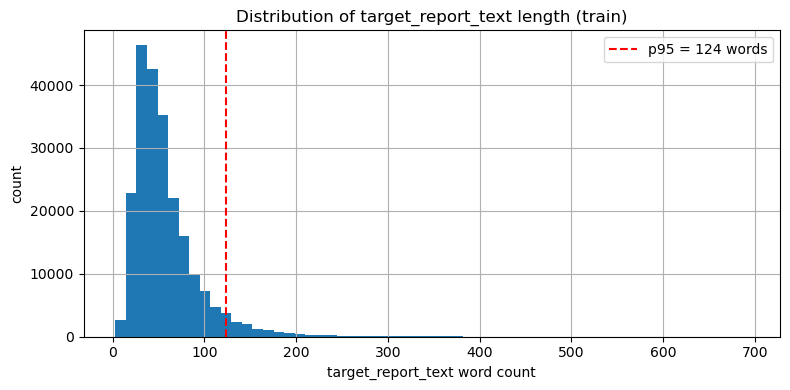


rows exceeding p95 budget (124 words): train 4.99%, test 5.56%


In [37]:
df_train['target_words'] = df_train['target_report_text'].str.split().str.len()
df_test['target_words'] = df_test['target_report_text'].str.split().str.len()

percentiles = df_train['target_words'].describe(percentiles=[.5, .75, .9, .95, .99])
print("[TRAIN SPLIT] target_report_text word count distribution:")
print(percentiles)

p95 = int(df_train['target_words'].quantile(0.95))
p99 = int(df_train['target_words'].quantile(0.99))
print(f"\nrecommended max_length budget (word-level, 95th percentile): {p95}")
print(f"recommended max_length budget (word-level, 99th percentile): {p99}")
print("note: convert to a token-level budget once the BioGPT tokenizer is loaded.")

# visualize distribution + mark the p95 cutoff
fig, ax = plt.subplots(figsize=(8, 4))
df_train['target_words'].hist(bins=60, ax=ax)
ax.axvline(p95, color='red', linestyle='--', label=f'p95 = {p95} words')
ax.set_xlabel('target_report_text word count')
ax.set_ylabel('count')
ax.set_title('Distribution of target_report_text length (train)')
ax.legend()
plt.tight_layout()
plt.show()

# quick check: how many rows would be truncated at the recommended p95 budget
train_truncated_pct = (df_train['target_words'] > p95).mean() * 100
test_truncated_pct = (df_test['target_words'] > p95).mean() * 100
print(f"\nrows exceeding p95 budget ({p95} words): train {train_truncated_pct:.2f}%, test {test_truncated_pct:.2f}%")

In [38]:
# auxiliary classifier label preparation

CHEXPERT_LABELS = [col.replace('_y', '') for col in impression_cols]

def build_pathology_labels(df: pd.DataFrame, pathology_cols: list, priority: str = "findings") -> pd.DataFrame:
    """
    combine findings (_x) and impression (_y) labels into a single target.

    clinical rules applied:
    1. u-ones convention: maps uncertain labels (-1.0) to positive (1.0).
    2. priority routing: `priority` decides which section wins when both exist.
    3. fallback routing: falls back to the other section if the priority one is NaN.
    4. default value: fills remaining unmentioned cases with negative (0.0).

    priority="findings" (default): findings-derived label wins, fallback to impression.
        Use this for the AUXILIARY IMAGE CLASSIFIER target — CheXpert Plus's own
        validation (Chambon et al., 2024, Table 4) shows CheXbert labels derived
        from Findings agree more closely with image-based ground truth (F1=0.44,
        n=154) than labels derived from Impression alone (F1=0.34). Since the
        classifier predicts pathology *from the image*, the more image-grounded
        text source should be prioritized.

    priority="impression": impression-derived label wins, fallback to findings.
        Impression is denser (present in ~99% of reports vs ~26% for findings)
        and represents the radiologist's final diagnostic conclusion. Keep this
        option available for any future use case that needs maximum label
        coverage rather than maximum image-fidelity (e.g. a text-only auxiliary
        signal, or general dataset statistics).

    Caveat: the n=154 comparison behind the "findings" default is a small,
    directional finding (no reported confidence interval), not a statistically
    confirmed effect size — i treat it as the better-supported default, not
    an absolute rule.
    """
    if priority not in ("findings", "impression"):
        raise ValueError(f"priority must be 'findings' or 'impression', got {priority!r}")

    labels = pd.DataFrame(index=df.index)

    for col in pathology_cols:
        # rule 1: apply u-ones mapping for uncertainty resolution
        col_x = df[f"{col}_x"].replace(-1.0, 1.0)   # findings-derived
        col_y = df[f"{col}_y"].replace(-1.0, 1.0)   # impression-derived

        # rule 2, 3, & 4: priority section -> fallback to the other -> default negative
        if priority == "findings":
            combined = col_x.fillna(col_y).fillna(0.0)
        else:
            combined = col_y.fillna(col_x).fillna(0.0)

        labels[col] = combined

    return labels

# build and merge labels for training dataset
# priority="findings" (default) -> intended for the image auxiliary classifier
train_pathology = build_pathology_labels(df_train, CHEXPERT_LABELS)
df_train = pd.concat([df_train, train_pathology.add_suffix('_label')], axis=1)

# build and merge labels for validation/test dataset
test_pathology = build_pathology_labels(df_test, CHEXPERT_LABELS)
df_test = pd.concat([df_test, test_pathology.add_suffix('_label')], axis=1)

In [39]:
df_train['is_frontal'] = df_train['frontal_lateral'] == 'Frontal'
df_test['is_frontal'] = df_test['frontal_lateral'] == 'Frontal'

In [40]:
# sanity check: positive rate per pathology after combining (train split)
label_cols = [f"{c}_label" for c in CHEXPERT_LABELS]
# measure pathology distribution in train split
print("[TRAIN SPLIT] PATHOLOGY POSITIVE RATE")
train_prevalence = (df_train[label_cols] == 1.0).mean().sort_values(ascending=False)
display(train_prevalence)
# measure pathology distribution in test split
print("\n[TEST SPLIT] PATHOLOGY POSITIVE RATE")
test_prevalence = (df_test[label_cols] == 1.0).mean().sort_values(ascending=False)
display(test_prevalence)

[TRAIN SPLIT] PATHOLOGY POSITIVE RATE


No Finding_label                    0.768526
Support Devices_label               0.590133
Lung Opacity_label                  0.510323
Pleural Effusion_label              0.457766
Atelectasis_label                   0.332526
Edema_label                         0.297626
Consolidation_label                 0.191759
Cardiomegaly_label                  0.185910
Enlarged Cardiomediastinum_label    0.145608
Pneumonia_label                     0.112151
Pneumothorax_label                  0.092652
Lung Lesion_label                   0.055430
Fracture_label                      0.049146
Pleural Other_label                 0.036285
dtype: float64


[TEST SPLIT] PATHOLOGY POSITIVE RATE


No Finding_label                    0.752137
Support Devices_label               0.504274
Lung Opacity_label                  0.380342
Pleural Effusion_label              0.329060
Atelectasis_label                   0.316239
Edema_label                         0.260684
Cardiomegaly_label                  0.162393
Consolidation_label                 0.158120
Pneumonia_label                     0.106838
Enlarged Cardiomediastinum_label    0.094017
Pneumothorax_label                  0.072650
Lung Lesion_label                   0.064103
Fracture_label                      0.059829
Pleural Other_label                 0.029915
dtype: float64

In [41]:
patient_labels = (df_train.groupby('deid_patient_id')[label_cols].max().reset_index())
X_dummy = patient_labels[['deid_patient_id']].values
y_labels = patient_labels[label_cols].values

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, dev_idx = next(msss.split(X_dummy, y_labels))

train_patients = set(patient_labels.iloc[train_idx]['deid_patient_id'])
dev_patients = set(patient_labels.iloc[dev_idx]['deid_patient_id'])

assert len(train_patients & dev_patients) == 0, "there is a patient level leakage between split"

df_train_internal = df_train[df_train['deid_patient_id'].isin(train_patients)].copy()
df_dev_internal = df_train[df_train['deid_patient_id'].isin(dev_patients)].copy()

In [42]:
print(f"train-internal: {len(df_train_internal)} rows ({len(train_patients)} patients)")
print(f"dev-internal:   {len(df_dev_internal)} rows ({len(dev_patients)} patients)")

# =====================================================================
#         log configuration & distribution validation
# =====================================================================
print("\n==========================================================")
print("       multi-label stratification success report          ")
print("==========================================================")

# calculate total samples for percentage calculation
total_samples = len(df_train_internal) + len(df_dev_internal) + len(df_test)

print(f" total size of dataset : {total_samples} samples")
print(f" data train internal   : {len(df_train_internal)} samples ({len(df_train_internal)/total_samples*100:.2f}%)")
print(f" data dev internal     : {len(df_dev_internal)} samples ({len(df_dev_internal)/total_samples*100:.2f}%)")
print(f" data test final       : {len(df_test)} samples ({len(df_test)/total_samples*100:.2f}%)")
print("==========================================================\n")

# calculate distribution to ensure balance of 14 pathologies (only count positive label 1.0)
dist_check = pd.DataFrame({
    'train (%)': (df_train_internal[label_cols] == 1.0).mean() * 100,
    'valid (%)': (df_dev_internal[label_cols] == 1.0).mean() * 100,
    'test (%)': (df_test[label_cols] == 1.0).mean() * 100
})

# add max difference/deviation column among the three splits
dist_check['max diff (%)'] = (
    dist_check[['train (%)', 'valid (%)', 'test (%)']].max(axis=1) - 
    dist_check[['train (%)', 'valid (%)', 'test (%)']].min(axis=1)
)

print("=== pathology class distribution balance (%) ===")
print("note: 'max diff' shows the maximum difference between splits (closer to 0 is better)\n")

# sort from highest difference to lowest to easily detect imbalance
dist_check_sorted = dist_check.sort_values('max diff (%)', ascending=False)

try:
    display(dist_check_sorted.round(2))
except NameError:
    print(dist_check_sorted.round(2))
print("\n==========================================================\n")

train-internal: 189622 rows (54820 patients)
dev-internal:   33470 rows (9688 patients)

       multi-label stratification success report          
 total size of dataset : 223326 samples
 data train internal   : 189622 samples (84.91%)
 data dev internal     : 33470 samples (14.99%)
 data test final       : 234 samples (0.10%)

=== pathology class distribution balance (%) ===
note: 'max diff' shows the maximum difference between splits (closer to 0 is better)



,train (%),valid (%),test (%),max diff (%)
Lung Opacity_label,51.05,50.94,38.03,13.01
Pleural Effusion_label,45.87,45.26,32.91,12.96
Support Devices_label,58.89,59.74,50.43,9.31
Enlarged Cardiomediastinum_label,14.59,14.39,9.40,5.19
Edema_label,29.75,29.82,26.07,3.75
Consolidation_label,19.13,19.41,15.81,3.60
Cardiomegaly_label,18.65,18.26,16.24,2.41
Pneumothorax_label,9.25,9.33,7.26,2.07
No Finding_label,76.83,76.99,75.21,1.78
Atelectasis_label,33.33,32.83,31.62,1.70


In [43]:
# =====================================================================
#                     storage / save file section
# =====================================================================
path = Path(r"D:\VLM-Research_Task-C\data\processed\chexpert_plus")
path.mkdir(parents=True, exist_ok=True)

train_output_path = path / "train"
dev_output_path = path / "dev_internal"
test_output_path = path / "test"

# save as parquet
df_train_internal.to_parquet(train_output_path.with_suffix('.parquet'), index=False)
df_dev_internal.to_parquet(dev_output_path.with_suffix('.parquet'), index=False)
df_test.to_parquet(test_output_path.with_suffix('.parquet'), index=False)

# save as csv
df_train_internal.to_csv(train_output_path.with_suffix('.csv'), index=False)
df_dev_internal.to_csv(dev_output_path.with_suffix('.csv'), index=False)
df_test.to_csv(test_output_path.with_suffix('.csv'), index=False)

print(f"process completed! all files successfully saved to directory: {path}")

process completed! all files successfully saved to directory: D:\VLM-Research_Task-C\data\processed\chexpert_plus


notes:
- train_internal and dev_internal is for model development only. These are official from train set of CheXpert Plus.
- test is for generalization error only (model evaluation). This is official from test set of CheXpert Plus.
- Design Decision: Include both frontal and lateral.

In [44]:
suspicious = df_train['cleaned_findings'].str.contains(r'\bimpression\s*:', case=False, regex=True, na=False)
print(f"baris dengan literal 'impression:' di cleaned_findings: {suspicious.sum()}")

if suspicious.sum() > 0:
    display(df_train.loc[suspicious, 'cleaned_findings'].head(10))

baris dengan literal 'impression:' di cleaned_findings: 0
